# Load sparse A and vector b from message-4.txt

We will parse the very large, very sparse matrix A and the right-hand side vector b from `message-4.txt` efficiently using streaming and SciPy sparse matrices, then visualize A's sparsity pattern.

Outline:
- Parse file to determine nrows and ncols for A and b
- Stream rows to build a COO sparse matrix for A (then convert to CSR)
- Extract b values
- Report shapes and density, then visualize with a sparsity plot

In [3]:
# Imports and parser utilities
from __future__ import annotations
import re
from pathlib import Path
from typing import Iterator, Tuple, List
import numpy as np
import matplotlib.pyplot as plt
from scipy import sparse

DATA_PATH = Path('/home/nandan_diwan/Desktop/optimization/argon_solver/constraint_test/message-4.txt')

# --- Helpers ---
_float_re = re.compile(r'[+-]?(?:\d+(?:\.\d*)?|\.\d+)(?:[eE][+-]?\d+)?')

def _parse_dims(line: str) -> Tuple[int, int]:
    """Extract nrows & ncols from a line like `nrows: Dyn(196), ncols: Dyn(212)`.
    If no dims found, raise ValueError.
    """
    nrows = ncols = None
    m_rows = re.search(r"nrows:\s*\w+\((\d+)\)", line)
    m_cols = re.search(r"ncols:\s*\w+\((\d+)\)", line)
    if m_rows:
        nrows = int(m_rows.group(1))
    if m_cols:
        ncols = int(m_cols.group(1))
    if nrows is None or ncols is None:
        raise ValueError('Could not determine nrows and ncols from line: ' + line[:200])
    return nrows, ncols

def _numbers_in(text: str) -> List[float]:
    """Return all floats found in the given text using a robust regex."""
    return [float(x) for x in _float_re.findall(text)]

def _extract_bracket_segment_before(text: str, pos: int) -> str:
    """Find the last '[' before pos and its matching ']' and return the bracket content including brackets."""
    prefix = text[:pos]
    lb = prefix.rfind('[')
    if lb == -1:
        raise ValueError('Could not find opening [ for A before dims marker')
    rb = text.find(']', lb)
    if rb == -1:
        raise ValueError('Could not find closing ] for A after opening [')
    return text[lb:rb+1]

def _extract_first_bracket_after(text: str, pos: int) -> str:
    """Find the first '[' after pos and its closing ']' and return the bracket content including brackets."""
    lb = text.find('[', pos)
    if lb == -1:
        raise ValueError('Could not find opening [ after given position')
    rb = text.find(']', lb)
    if rb == -1:
        raise ValueError('Could not find closing ] after opening [')
    return text[lb:rb+1]

def load_sparse_A_b(path: Path) -> Tuple[sparse.csr_matrix, np.ndarray]:
    """Parse message-4.txt into sparse matrix A and vector b.

    Observed format:
    - A: very long list `[ ... ]` followed by a dims annotation like `nrows: Dyn(R), ncols: Dyn(C)`
    - b: appears in a `VecStorage { data: [ ... ], nrows: Dyn(R), ... }` that follows A
    """
    text = path.read_text(errors='ignore')

    # Locate dims for A
    m_dims = re.search(r"nrows:\s*\w+\(\d+\)\s*,\s*ncols:\s*\w+\(\d+\)", text)
    if not m_dims:
        raise ValueError('Dimensions not found in file for A.')
    nrows, ncols = _parse_dims(m_dims.group(0))

    # Extract A numbers strictly from the last [...] before dims
    a_segment = _extract_bracket_segment_before(text, m_dims.start())
    a_vals = _numbers_in(a_segment)
    needed = nrows * ncols
    if len(a_vals) < needed:
        raise ValueError(f'Not enough numeric tokens for A: have {len(a_vals)}, need {needed}')
    # If extra, take the last needed (in case the bracket contained more for some reason)
    a_vals = a_vals[-needed:]

    # Build sparse A (COO -> CSR)
    rows: List[int] = []
    cols: List[int] = []
    data: List[float] = []
    for idx, val in enumerate(a_vals):
        if val != 0.0:
            r = idx // ncols
            c = idx % ncols
            rows.append(r)
            cols.append(c)
            data.append(val)
    A = sparse.coo_matrix((data, (rows, cols)), shape=(nrows, ncols)).tocsr()

    # Extract b numbers from the first [...] after the word 'VecStorage' following dims
    # Prefer the bracket after 'VecStorage', else fallback to the first bracket after dims
    after_dims_pos = m_dims.end()
    m_vec = re.search(r"VecStorage", text[after_dims_pos:])
    if m_vec:
        vec_pos = after_dims_pos + m_vec.start()
        b_segment = _extract_first_bracket_after(text, vec_pos)
    else:
        b_segment = _extract_first_bracket_after(text, after_dims_pos)
    b_vals = _numbers_in(b_segment)
    if len(b_vals) < nrows:
        raise ValueError(f'Parsed b has length {len(b_vals)}, expected at least {nrows}')
    b = np.array(b_vals[:nrows], dtype=float)

    return A, b

print('Utilities loaded. File exists:', DATA_PATH.exists())

Utilities loaded. File exists: True


In [7]:
# Build A and b
A, b = load_sparse_A_b(DATA_PATH)
print('A shape:', A.shape)
print('b shape:', b.shape)
nnz = A.nnz
nrows, ncols = A.shape
density = nnz / (nrows * ncols)
print(f'nonzeros: {nnz}, density: {density:.6e}')

A shape: (196, 212)
b shape: (196,)
nonzeros: 392, density: 9.433962e-03


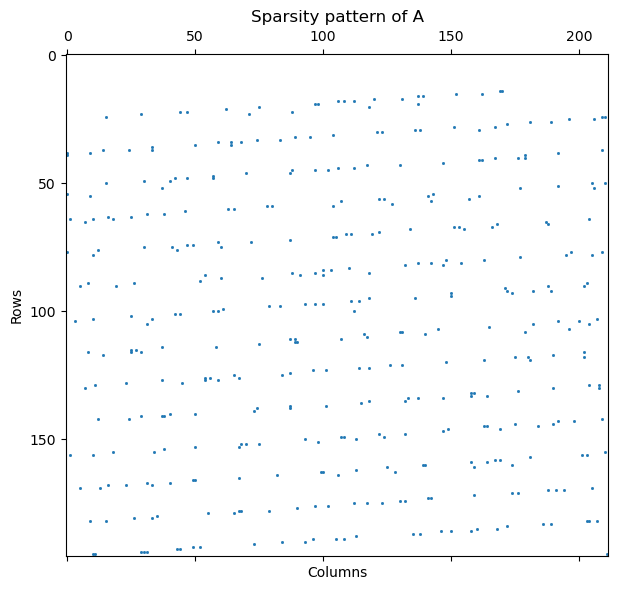

In [5]:
# Visualize A sparsity
plt.figure(figsize=(8, 6))
plt.spy(A, markersize=1)
plt.title('Sparsity pattern of A')
plt.xlabel('Columns')
plt.ylabel('Rows')
plt.tight_layout()
plt.show()

In [6]:
# Optionally persist artifacts for reuse
OUT_DIR = DATA_PATH.parent / 'artifacts'
OUT_DIR.mkdir(exist_ok=True)
sparse.save_npz(OUT_DIR / 'A.npz', A)
np.save(OUT_DIR / 'b.npy', b)
print('Saved:', OUT_DIR)

Saved: /home/nandan_diwan/Desktop/optimization/argon_solver/constraint_test/artifacts


In [10]:
# Solve Ax = b using sparse methods
from scipy.sparse.linalg import spsolve, lsmr, lsqr, cg, gmres

def solve_system(A, b):
    nrows, ncols = A.shape
    # Choose method based on shape
    if nrows == ncols:
        # Try direct sparse solve first
        try:
            x = spsolve(A, b)
            method = 'spsolve'
        except Exception as e:
            print('spsolve failed:', type(e).__name__, e)
            # Fall back to GMRES (restart)
            x, info = gmres(A, b, tol=1e-8, restart=min(50, ncols))
            method = f'gmres(info={info})'
    else:
        # Over/underdetermined -> least squares
        x = lsmr(A, b, atol=1e-10, btol=1e-10, maxiter=500)[0]
        method = 'lsmr'
    return x, method

x, method = solve_system(A, b)
res = A @ x - b
rel_res = np.linalg.norm(res) / max(np.linalg.norm(b), 1e-12)
print(f'Method: {method}')
print('||A x - b||:', float(np.linalg.norm(res)))
print('Relative residual:', float(rel_res))
print('x shape:', x.shape)

Method: lsmr
||A x - b||: 148.59660610295174
Relative residual: 0.798860303524151
x shape: (212,)
